In [1]:
import sns

from utils.constants import *
import shutil
import kagglehub
"""
pip install kagglehub[pandas-datasets] to download dataset
"""

os.makedirs('gtrsb_dataset', exist_ok=True)
dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"Dataset downloaded to: {dataset_path}")

# move the dataset to current project directory
target_path = './gtrsb_dataset'
if os.path.exists(target_path):
    shutil.move(dataset_path, target_path)

Resuming download from 78643200 bytes (562925592 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign?dataset_version_number=1 (78643200/641568792) bytes left.


100%|██████████| 612M/612M [00:34<00:00, 16.3MB/s] 

Extracting files...


Dataset downloaded to: C:\Users\nick\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1


Error: Destination path './gtrsb_dataset\1' already exists

In [2]:
from pathlib import Path
import pandas as pd

# Get the root path of the dataset
DATA_ROOT = Path("gtrsb_dataset") / "1"

# Make dataset tables available in variables
start_train_df = pd.read_csv(DATA_ROOT / "Train.csv")
start_test_df = pd.read_csv(DATA_ROOT / "Test.csv")
meta_df = pd.read_csv(DATA_ROOT / "Meta.csv")

# Ensure consistent column naming
start_train_df.rename(columns=lambda x: x.strip().lower(), inplace=True)
start_test_df.rename(columns=lambda x: x.strip().lower(), inplace=True)
meta_df.rename(columns=lambda x: x.strip().lower(), inplace=True)

# Join on 'classid'
train_df = pd.merge(start_train_df, meta_df, on="classid", how="left")
train_df = train_df.drop(["width", "height", "roi.x1", "roi.y1", "roi.x2", "roi.y2", "path_x", "path_y"], axis=1)
test_df = pd.merge(start_test_df, meta_df, on="classid", how="left")
test_df = test_df.drop(["width", "height", "roi.x1", "roi.y1", "roi.x2", "roi.y2", "path_x", "path_y"], axis=1)

# Display data
display(train_df)
display(test_df)


,classid,shapeid,colorid,signid
0,20,0,0,1.1
1,20,0,0,1.1
2,20,0,0,1.1
3,20,0,0,1.1
4,20,0,0,1.1
...,...,...,...,...
39204,42,1,3,3.28
39205,42,1,3,3.28
39206,42,1,3,3.28
39207,42,1,3,3.28


,classid,shapeid,colorid,signid
0,16,1,0,3.3
1,1,1,0,3.29
2,38,1,1,4.7
3,33,1,1,4.2
4,11,0,0,1.22
...,...,...,...,...
12625,12,2,2,2.3
12626,33,1,1,4.2
12627,6,1,3,3.3
12628,7,1,0,3.29


- Split dataset
- knn trainieren
-

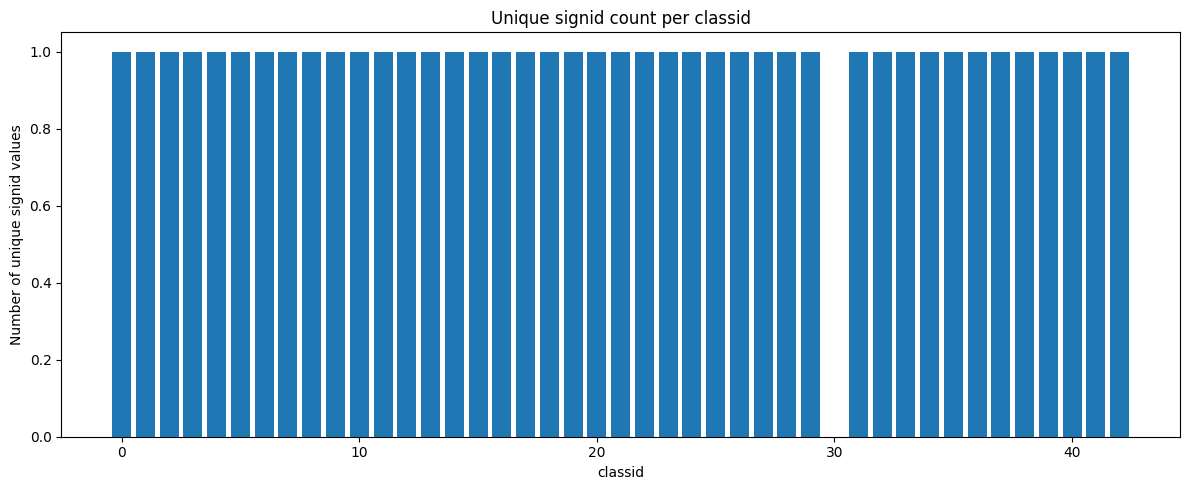

signid
1.1     2
3.29    8
3.3     2
4.1     2
Name: classid, dtype: int64


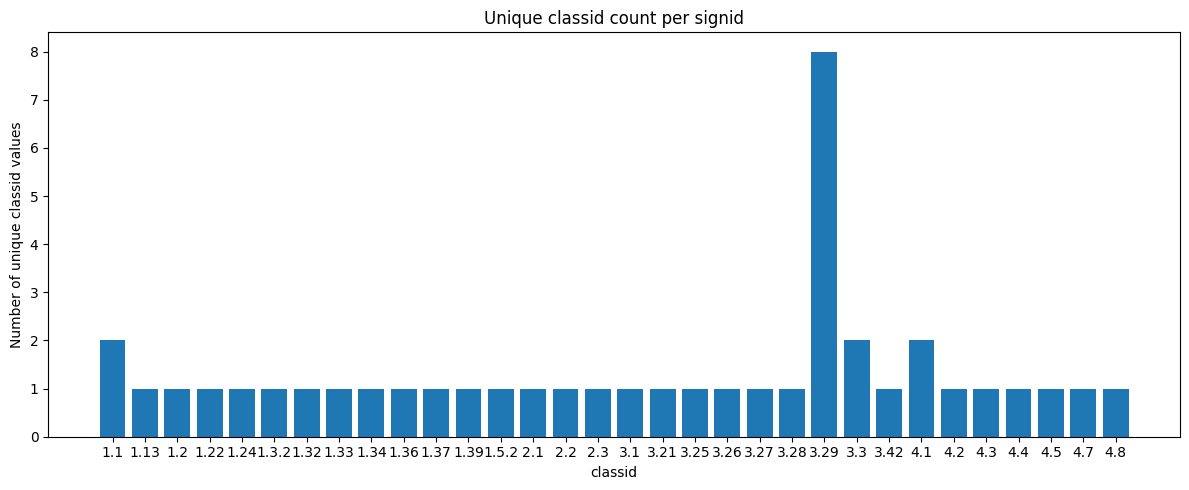

signid
1.1     2
3.29    8
3.3     2
4.1     2
Name: classid, dtype: int64


In [3]:
import matplotlib.pyplot as plt

# Compute number of unique signids per classid
unique_counts = train_df.groupby("classid")["signid"].nunique().sort_index()

# Plot
plt.figure(figsize=(12, 5))
plt.bar(unique_counts.index, unique_counts.values)
plt.xlabel("classid")
plt.ylabel("Number of unique signid values")
plt.title("Unique signid count per classid")
plt.tight_layout()
plt.show()

inconsistent = train_df.groupby("signid")["classid"].nunique()
inconsistent = inconsistent[inconsistent > 1]
print(inconsistent)

# Compute number of unique signids per classid
unique_counts = train_df.groupby("signid")["classid"].nunique().sort_index()

# Plot
plt.figure(figsize=(12, 5))
plt.bar(unique_counts.index, unique_counts.values)
plt.xlabel("classid")
plt.ylabel("Number of unique classid values")
plt.title("Unique classid count per signid")
plt.tight_layout()
plt.show()

inconsistent = train_df.groupby("signid")["classid"].nunique()
inconsistent = inconsistent[inconsistent > 1]
print(inconsistent)